# Resonance finding via reflected power (2-3 GHz)

Setup: generator -> bidirectional coupler forward port -> resonant structure. Coupler's REVERSE (reflected) port -> spectrum analyzer. A resonance shows up as a dip in reflected power at the resonant frequency (structure absorbs/couples power instead of reflecting it).

Plan: coarse 1 MHz sweep across the full 2-3 GHz range to locate the dip, then a fine sweep zoomed in around it to pin down the resonant frequency precisely. Output power kept low (-20 dBm) throughout.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from hp8673h import HP8673H
from e4403b import E4403B
from frequency_sweep import frequency_sweep

In [2]:
gen = HP8673H("GPIB1::19::INSTR")
sa = E4403B("GPIB0::18::INSTR")

START_HZ = 2.0e9
STOP_HZ = 3.0e9
COARSE_STEP_HZ = 1e6
POWER_DBM = -20

HP8673H: connected
E4403B: connected


## Coarse sweep: 2-3 GHz, 1 MHz steps

In [3]:
sa.set_center_span((START_HZ + STOP_HZ) / 2, STOP_HZ - START_HZ)

coarse_freqs_hz, coarse_power_dbm = frequency_sweep(
    gen, sa,
    start_hz=START_HZ, stop_hz=STOP_HZ, step_hz=COARSE_STEP_HZ,
    power_dbm=POWER_DBM,
)

print(f"{len(coarse_freqs_hz)} points collected")

1001 points collected


coarse resonance dip: 2.0460 GHz, -52.5 dBm


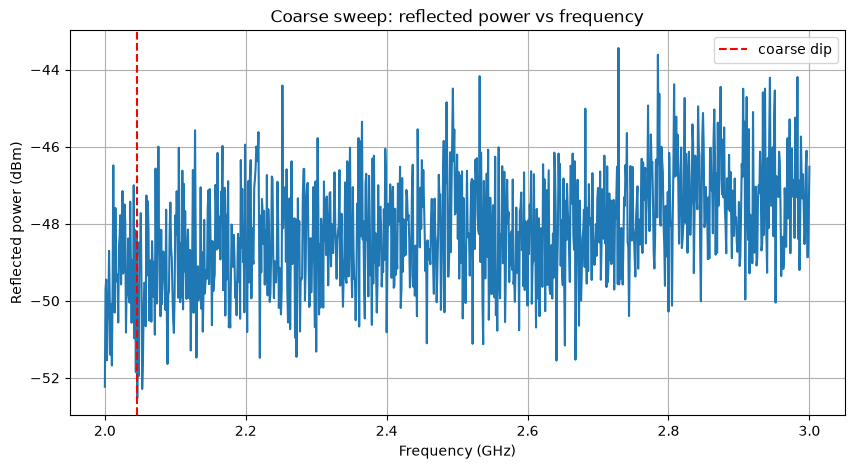

In [4]:
dip_idx = np.argmin(coarse_power_dbm)
coarse_dip_freq = coarse_freqs_hz[dip_idx]
coarse_dip_power = coarse_power_dbm[dip_idx]
print(f"coarse resonance dip: {coarse_dip_freq/1e9:.4f} GHz, {coarse_dip_power:.1f} dBm")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(coarse_freqs_hz / 1e9, coarse_power_dbm)
ax.axvline(coarse_dip_freq / 1e9, color='r', linestyle='--', label='coarse dip')
ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("Reflected power (dBm)")
ax.set_title("Coarse sweep: reflected power vs frequency")
ax.legend()
ax.grid(True)
plt.show()

## Fine sweep around the coarse dip

In [5]:
FINE_SPAN_HZ = 10e6
FINE_STEP_HZ = 20e3

fine_start = coarse_dip_freq - FINE_SPAN_HZ / 2
fine_stop = coarse_dip_freq + FINE_SPAN_HZ / 2

sa.set_center_span(coarse_dip_freq, FINE_SPAN_HZ)

fine_freqs_hz, fine_power_dbm = frequency_sweep(
    gen, sa,
    start_hz=fine_start, stop_hz=fine_stop, step_hz=FINE_STEP_HZ,
    power_dbm=POWER_DBM,
)

gen.close()
sa.close()

print(f"{len(fine_freqs_hz)} points collected")

501 points collected


resonance frequency: 2.044340 GHz
reflected power at resonance: -77.5 dBm
dip depth vs off-resonance (max in fine sweep): 17.6 dB


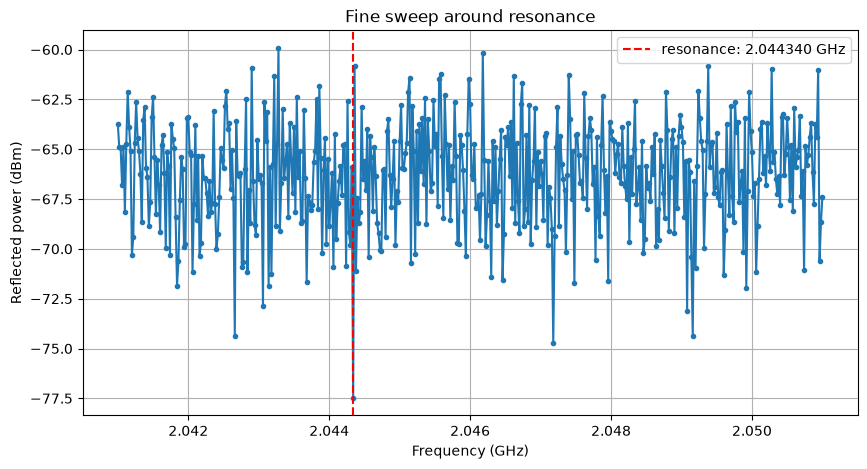

In [6]:
fine_dip_idx = np.argmin(fine_power_dbm)
resonance_freq = fine_freqs_hz[fine_dip_idx]
resonance_power = fine_power_dbm[fine_dip_idx]
print(f"resonance frequency: {resonance_freq/1e9:.6f} GHz")
print(f"reflected power at resonance: {resonance_power:.1f} dBm")
print(f"dip depth vs off-resonance (max in fine sweep): "
      f"{fine_power_dbm.max() - resonance_power:.1f} dB")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(fine_freqs_hz / 1e9, fine_power_dbm, marker='.')
ax.axvline(resonance_freq / 1e9, color='r', linestyle='--',
           label=f'resonance: {resonance_freq/1e9:.6f} GHz')
ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("Reflected power (dBm)")
ax.set_title("Fine sweep around resonance")
ax.legend()
ax.grid(True)
plt.show()

In [ ]:
np.savetxt(
    "data/resonance_coarse_sweep_2-3GHz_1MHz.csv",
    np.column_stack((coarse_freqs_hz, coarse_power_dbm)),
    delimiter=",", header="frequency_hz,power_dbm", comments="",
)
np.savetxt(
    "data/resonance_fine_sweep.csv",
    np.column_stack((fine_freqs_hz, fine_power_dbm)),
    delimiter=",", header="frequency_hz,power_dbm", comments="",
)